PYTHON PROJECT NO. 1

Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Data

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")

I'm using the methods df.describe(), df.head() and df.columns to see the data

In [ ]:
df.describe()

,Year,Total Tested
count,212331.000000,212331.000000
mean,2015.956069,49.364200
std,0.799726,93.023576
min,2015.000000,1.000000
25%,2015.000000,5.000000
50%,2016.000000,20.000000
75%,2017.000000,57.000000
max,2017.000000,1729.000000


In [ ]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [ ]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

I want to compare the performance of the schools from the start of the dataset to the last year recorded. I would like to see if the schools scores improved or declined.

I'm using the methods min() and max() to know the first and last year recorded in the data

In [ ]:
first_year = df["Year"].min()
print(first_year)

2015


In [ ]:
last_year = df["Year"].max()
print(last_year)

2017


I'm using the Mean Score as parameter to compare performance



Cleaning data:

 I need all values to be numeric since some values are using strings ("s"). I'm using errors = "coerce" to replace all string values with an indication that they are Non numeric value. Then, I'm using .dropna to remove all the Non numeric values.

In [ ]:
df['Mean Score']=pd.to_numeric(df['Mean Score'],errors='coerce')

Using df.nunique() to see the original unique number of schools before cleaning

In [ ]:
df.nunique()

,0
School DBN,1018
School Name,1012
School Level,6
Regents Exam,14
Year,3
Total Tested,1126
Mean Score,747
Number Scoring Below 65,446
Percent Scoring Below 65,992
Number Scoring 65 or Above,945


In [ ]:
df_subset = df.dropna(subset=['Mean Score'])
df_subset.nunique()


,0
School DBN,971
School Name,965
School Level,6
Regents Exam,14
Year,3
Total Tested,1118
Mean Score,747
Number Scoring Below 65,445
Percent Scoring Below 65,991
Number Scoring 65 or Above,944


Now I'm assigning a single score per year to each school using Groupby. I need to use as_index=False to have one row per year (It was giving me an error before)

In [ ]:
df_score_year = df_subset.groupby(["School DBN", "School Name", "Year" ], as_index=False)["Mean Score"].mean()
df_score_year.head()

,School DBN,School Name,Year,Mean Score
0,01M034,P.S. 034 Franklin D. Roosevelt,2015,78.000000
1,01M034,P.S. 034 Franklin D. Roosevelt,2016,73.833333
2,01M140,P.S. 140 Nathan Straus,2015,67.400000
3,01M140,P.S. 140 Nathan Straus,2016,73.100000
4,01M140,P.S. 140 Nathan Straus,2017,65.725000


Now I'm comparing the overall school performance in 2015 (first year of data) to the performance in 2017 (last date of data)

In [ ]:
df_first = df_score_year[df_score_year["Year"] == 2015]

In [ ]:
df_last = df_score_year[df_score_year["Year"] == 2017]

In [ ]:
df_first_mean = df_first["Mean Score"].mean()
print(df_first_mean)

67.69100510441547


In [ ]:
df_last_mean = df_last["Mean Score"].mean()
print(df_last_mean)


69.30418966745202


Now I can see that the mean score for all schools improved in 2017.

I also want to find the best school in the best year (2017)

In [ ]:
df_2017 = df_score_year[df_score_year["Year"] == 2017]

In [ ]:
top_school = df_2017.sort_values(by="Mean Score", ascending=False).head(1)
print(top_school)


   School DBN              School Name  Year  Mean Score
52     02M114  East Side Middle School  2017        94.1


I'm using histogram to see the scores for 2017 (best year)

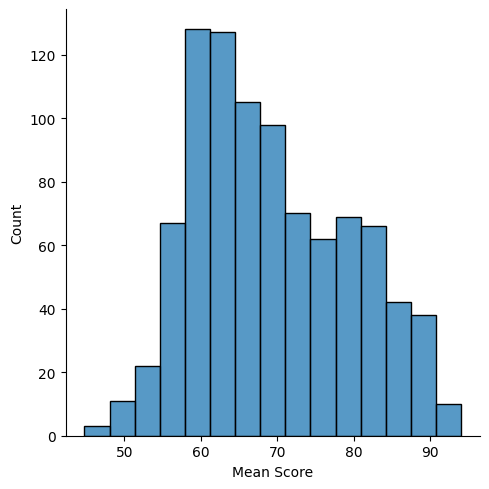

In [ ]:
sns.displot(df_2017["Mean Score"])


I can see here that the highest counts are for scores around the 60 mark, whih make sense since the overall mean for 2017 was 69.3.  

<Axes: xlabel='Year', ylabel='Mean Score'>

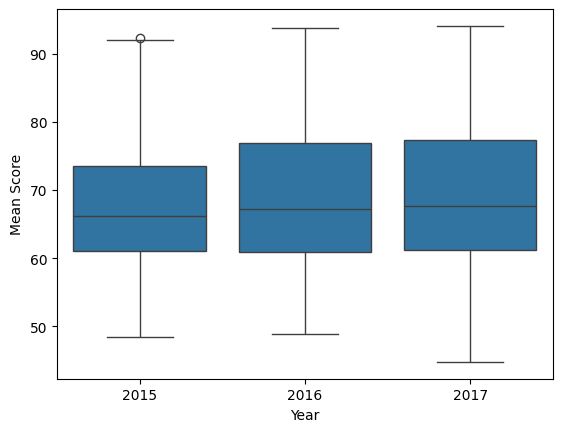

In [ ]:
sns.boxplot(x="Year", y="Mean Score", data=df_score_year)

This graph shows that the scores improved from the first year recorded (2015) to the last year of data (2017). This visual representation supports the conclusion previously obatained with the numerical comparison.